# Yearly TF-IDF ? `made_it_contract` Analysis

Capture per-year language summaries, dashboards for term shifts, and a single pipeline that trains on 2014-2021 (the only years with reliable second-contract labels) while projecting the model onto 2022-2025.


In [101]:
import re
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import average_precision_score
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [102]:
from pathlib import Path
ROOT = Path('..')  # repo root, relative to notebooks/
path = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
raw = pd.read_csv(path, low_memory=False)
df = raw.query('2014 <= year <= 2025').copy()
text_cols = ['overview', 'strengths', 'weaknesses']
df[text_cols] = df[text_cols].fillna('')
df['scouting_text'] = (
    df[text_cols].agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
numeric_cols = ['grade', 'total_score', 'production_score', 'athleticism_score']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Pos_Group'] = df['Pos_Group'].fillna('UNKNOWN')
df['made_it_contract'] = df['made_it_contract'].where(df.year <= 2021)
df = df.loc[(df['grade'] > 0) & (df['scouting_text'].str.strip() != '')].copy()
tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in tag_prefix.items():
    df[f'{col}_tagged'] = df[col].str.strip().replace('', pd.NA)
    df[f'{col}_tagged'] = df[f'{col}_tagged'].apply(lambda txt: f"{prefix}: {txt}" if pd.notna(txt) else '')

df['scouting_text_tagged'] = (
    df[[f'{col}_tagged' for col in text_cols]]
    .agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


## NFL-Aware Preprocessing (no phrase stitching)

Use domain-curated stop words from `nfl_pre_proc.ipynb` — un-stopping directional adjectives
("high", "low", "deep") and removing scouting filler ("prospect", "ability") — but **without**
compound phrase stitching. TF-IDF bigrams via `ngram_range=(1,2)` capture collocations naturally;
stitched tokens like `pass_rush` would inflate IDF by appearing in only 10-20% of docs.

In [103]:
# ── NFL stopword config (from nfl_pre_proc.ipynb) ────────────────────────────
# Directional adjectives NLTK would stop that carry real scouting meaning
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}
# Generic scouting filler: appears in nearly every report, zero discriminative signal
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
}
# Outcome-leaking phrases stripped before any processing
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]
_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS
_lemmatizer = WordNetLemmatizer()

print(f'NFL stop list: {len(NFL_STOPWORDS)} words '
      f'({len(KEEP_WORDS & _base_stops)} directionals un-stopped, {len(CUSTOM_STOPS)} filler added)')


def nfl_preprocess_no_stitch(text: str) -> str:
    """NFL-aware preprocessing without compound phrase stitching.

    Steps: lowercase → strip outcome-leaking phrases → normalize hyphens →
    alpha-only → tokenize → NFL stopwords → lemmatize.
    TF-IDF bigrams (ngram_range=(1,2)) capture collocations like 'pass rush'
    naturally without needing to stitch them into 'pass_rush' tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-\u2013\u2014]', ' ', text)   # normalize hyphens → space
    text = re.sub(r'[^a-z\s]', ' ', text)           # letters and spaces only
    tokens = text.split()
    tokens = [t for t in tokens if t not in NFL_STOPWORDS and len(t) > 1]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Apply preprocessing to each field independently, then rebuild scouting_text_tagged
_tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in _tag_prefix.items():
    df[f'{col}_clean'] = df[col].apply(nfl_preprocess_no_stitch)

def _build_tagged_clean(row):
    parts = [f"{prefix}: {row[f'{col}_clean']}"
             for col, prefix in _tag_prefix.items()
             if str(row[f'{col}_clean']).strip()]
    return ' '.join(parts)

df['scouting_text_tagged'] = df.apply(_build_tagged_clean, axis=1)
df = df.loc[df['scouting_text_tagged'].str.strip() != ''].copy()

# Quick sanity checks
token_counts = df['scouting_text_tagged'].str.split().str.len()
print(f'Players after preprocessing: {len(df)}')
print(f'Tokens/player — median: {int(token_counts.median())}, '
      f'mean: {token_counts.mean():.0f}, '
      f'min: {token_counts.min()}, max: {token_counts.max()}')
print()
# Verify key directionals kept, filler removed
sample = df['scouting_text_tagged'].iloc[0]
print('Sample (first 300 chars):')
print(sample[:300])

NFL stop list: 225 words (8 directionals un-stopped, 35 filler added)
Players after preprocessing: 5321
Tokens/player — median: 133, mean: 135, min: 30, max: 392

Sample (first 300 chars):
OVR: physical specimen rare size speed combination clowney impactful junior playing through injury forced deal opposing offense fully accounted extra chip protection old junior affected turnover defensive coaching staff could benefit tremendously stable positional coach strong veteran mentor defensi


In [104]:
def compute_yearly_tfidf(subset, vectorizer=None, weight_col='total_score', norm='sum'):
    subset = subset[subset['scouting_text_tagged'].str.strip() != '']
    if subset.empty:
        return None
    if vectorizer is None:
        vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
    X = vectorizer.fit_transform(subset['scouting_text_tagged'])
    weights = subset[weight_col].fillna(1.0).clip(lower=1.0)
    weighted = X.multiply(weights.values[:, None])
    denom = weights.sum() if norm == 'sum' else len(weights)
    denom = max(denom, 1.0)
    agg = np.asarray(weighted.sum(axis=0)).ravel() / denom
    return {
        'year': subset['year'].iloc[0],
        'vectorizer': vectorizer,
        'weights': agg,
        'vocab': vectorizer.get_feature_names_out(),
        'denom': denom,
    }

In [105]:
# Updated params: lower max_features + min_df floor to remove hapax bigrams,
# sublinear_tf=True since docs are ~150-200 tokens (TF is nearly binary at this length).
# stop_words removed — handled upstream by nfl_preprocess_no_stitch.
vectorizer_params = dict(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
years = range(2014, 2026)
yearly_info = {}
for year in years:
    info = compute_yearly_tfidf(
        df[df.year == year],
        vectorizer=TfidfVectorizer(**vectorizer_params),
        weight_col='total_score',
        norm='sum',
    )
    if info:
        yearly_info[year] = info

top_rows = []
for year, info in yearly_info.items():
    agg = info['weights']
    idx = np.argsort(agg)[::-1][:12]
    for rank, term_idx in enumerate(idx, 1):
        top_rows.append({
            'year': year,
            'rank': rank,
            'term': info['vocab'][term_idx],
            'score': float(agg[term_idx]),
        })
top_terms_df = pd.DataFrame(top_rows)
top_terms_df

,year,rank,term,score
0,2014,1,good,0.046391
1,2014,2,play,0.042610
2,2014,3,run,0.039578
3,2014,4,hand,0.038406
4,2014,5,off,0.038170
...,...,...,...,...
139,2025,8,lack,0.040064
140,2025,9,good,0.040024
141,2025,10,speed,0.037794
142,2025,11,rush,0.036357


### Bigram highlights

Filter the per-year summaries for multi-word phrases so you can see which skill/value bigrams stand out each class.

In [106]:
bigram_rows = []
for year, info in yearly_info.items():
    vocab = info['vocab']
    weights = info['weights']
    bigram_idx = [i for i, term in enumerate(vocab) if ' ' in term]
    if not bigram_idx:
        continue
    top_bigrams = sorted(bigram_idx, key=lambda i: weights[i], reverse=True)[:8]
    for rank, idx in enumerate(top_bigrams, 1):
        bigram_rows.append({
            'year': year,
            'rank': rank,
            'bigram': vocab[idx],
            'score': float(weights[idx]),
        })
bigram_terms_df = pd.DataFrame(bigram_rows)
bigram_terms_df.sort_values(['year', 'rank']).head(20)


,year,rank,bigram,score
0,2014,1,special team,0.021864
1,2014,2,str good,0.020161
2,2014,3,could stand,0.019367
3,2014,4,lack ideal,0.018835
4,2014,5,tight end,0.016344
5,2014,6,wkn lack,0.015176
6,2014,7,body control,0.014777
7,2014,8,ovr big,0.014739
8,2015,1,pas rusher,0.022476
9,2015,2,running back,0.018240


In [107]:
pivot = top_terms_df.pivot(index='term', columns='year', values='score').fillna(0)
training_cols = [y for y in pivot.columns if 2014 <= y <= 2021]
if training_cols:
    baseline = pivot[training_cols].mean(axis=1)
else:
    baseline = pd.Series(0, index=pivot.index)
latest = pivot[2025] if 2025 in pivot.columns else pd.Series(0, index=pivot.index)
deltas = (latest - baseline).dropna().sort_values(ascending=False).head(10).reset_index(name='score_delta')
deltas


,term,score_delta
0,rush,0.036357
1,average,0.026293
2,catch,0.026054
3,lack,0.022070
4,good,0.020293
5,block,0.020027
6,route,0.009069
7,run,0.003935
8,hand,0.001785
9,play,0.000769


## Classifier pipeline

We train on 2014-2021 where `made_it_contract` labels exist, compare PR-AUC to a grade+position baseline, and then project the text model onto 2022-2025.


In [108]:
numeric_features = ['grade', 'total_score', 'production_score', 'athleticism_score', 'year']
cat_features = ['Pos_Group']

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns]

class YearNormalizedTfidf(BaseEstimator, TransformerMixin):
    def __init__(self, text_column='scouting_text', year_column='year', vectorizer_params=None):
        self.text_column = text_column
        self.year_column = year_column
        self.vectorizer_params = vectorizer_params or {}
        self.vectorizer = TfidfVectorizer(**self.vectorizer_params)

    def fit(self, X, y=None):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.fit_transform(texts)
        arr = tfidf.toarray()
        self.year_means_ = {}
        for year in np.unique(years):
            mask = years == year
            if mask.sum():
                self.year_means_[year] = arr[mask].mean(axis=0)
        self.global_mean_ = arr.mean(axis=0)
        return self

    def transform(self, X):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.transform(texts)
        arr = tfidf.toarray()
        adjusted = arr.copy()
        for year, mean in self.year_means_.items():
            mask = years == year
            if mask.sum():
                adjusted[mask] -= mean
        unseen_mask = ~np.isin(years, list(self.year_means_.keys()))
        if unseen_mask.any():
            adjusted[unseen_mask] -= self.global_mean_
        return adjusted

text_pipeline = Pipeline([
    ('selector', ColumnSelector(['scouting_text_tagged', 'year'])),
    ('year_norm', YearNormalizedTfidf(text_column='scouting_text_tagged', vectorizer_params=vectorizer_params)),
])

meta_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='drop',
)

preprocessor = FeatureUnion([
    ('text', text_pipeline),
    ('meta', meta_transformer),
])

pipe = Pipeline([
    ('features', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1)),
])

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('grade', StandardScaler(), ['grade']),
        ('pos', OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
        ('year', StandardScaler(), ['year']),
    ],
    remainder='drop',
)
baseline_pipe = Pipeline([
    ('preproc', baseline_preprocessor),
    ('lr', LogisticRegression(max_iter=2000, solver='liblinear')),
])

train_mask = df.year.between(2014, 2021) & df.made_it_contract.notna()
train_df = df.loc[train_mask].copy()
train_df['made_it_contract'] = train_df['made_it_contract'].astype(int)
y_train = train_df['made_it_contract']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

positive_rate = y_train.mean()
desired_rate = 0.3
if positive_rate in (0, 1):
    pos_weight = neg_weight = 1.0
else:
    pos_weight = desired_rate / positive_rate
    neg_weight = (1 - desired_rate) / (1 - positive_rate)
baseline_weights = y_train * pos_weight + (1 - y_train) * neg_weight

text_scores = cross_val_score(pipe, train_df, y_train, cv=cv, scoring='average_precision')
baseline_scores = []
for train_idx, test_idx in cv.split(train_df, y_train):
    estimator = clone(baseline_pipe)
    estimator.fit(train_df.iloc[train_idx], y_train.iloc[train_idx], lr__sample_weight=baseline_weights.iloc[train_idx])
    preds = estimator.predict_proba(train_df.iloc[test_idx])[:, 1]
    baseline_scores.append(average_precision_score(y_train.iloc[test_idx], preds))
baseline_scores = np.array(baseline_scores)

print("Text + scores + pos PR-AUC: %.3f +- %.3f" % (text_scores.mean(), text_scores.std()))
print("Calibrated grade + Pos_Group PR-AUC: %.3f +- %.3f" % (baseline_scores.mean(), baseline_scores.std()))


Text + scores + pos PR-AUC: 0.562 +- 0.027
Calibrated grade + Pos_Group PR-AUC: 0.558 +- 0.029


In [109]:
pipe.fit(train_df, y_train)
baseline_pipe.fit(train_df, y_train, lr__sample_weight=baseline_weights)

future_df = df[df.year.between(2022, 2025)].copy()
future_df['pred_made_it'] = pipe.predict_proba(future_df)[:, 1]
future_df['baseline_score'] = baseline_pipe.predict_proba(future_df)[:, 1]
cols = ['year', 'player_name', 'team', 'Pos_Group', 'grade', 'total_score', 'pred_made_it', 'baseline_score']
future_summary = future_df.sort_values(['pred_made_it'], ascending=False)[cols].head(12)
future_summary


,year,player_name,team,Pos_Group,grade,total_score,pred_made_it,baseline_score
5418,2022,Kenny Pickett,Pittsburgh Steelers,QB,6.40,84.0,0.7125,0.452552
5396,2022,Evan Neal,New York Giants,OL,6.76,86.0,0.7075,0.700801
6355,2024,JC Latham,Tennessee Titans,OL,6.71,87.0,0.7050,0.648936
6843,2025,Cam Ward,Tennessee Titans,QB,6.39,86.0,0.7025,0.398382
6359,2024,Joe Alt,Los Angeles Chargers,OL,6.49,97.0,0.6975,0.540727
5412,2022,Malik Willis,Tennessee Titans,QB,6.41,80.0,0.6950,0.457637
6350,2024,Caleb Williams,Chicago Bears,QB,6.74,92.0,0.6800,0.592075
5863,2023,Bryce Young,Carolina Panthers,QB,6.82,90.0,0.6800,0.646502
5865,2023,Peter Skoronski,Tennessee Titans,OL,6.73,89.0,0.6700,0.673154
6819,2025,Travis Hunter,Jacksonville Jaguars,WR,6.89,92.0,0.6550,0.563144


### Section-specific TF-IDF + tagged tokens

Compare a pipeline that fits year-normalized TF-IDF separately for each text field (overview/strengths/weaknesses) with a single-vectorizer approach that tags each token with its section prefix. Both keep the context while still working on short documents.

In [110]:
section_cols = ['overview_clean', 'strengths_clean', 'weaknesses_clean']
section_pipelines = []
section_vectorizer_params = dict(max_features=500, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
for col in section_cols:
    section_pipelines.append((
        f'{col}_text',
        Pipeline([
            ('selector', ColumnSelector([col, 'year'])),
            ('year_norm', YearNormalizedTfidf(text_column=col, year_column='year', vectorizer_params=section_vectorizer_params)),
        ])
    ))
section_text_union = FeatureUnion(section_pipelines)
section_full_features = FeatureUnion([
    ('section_text', section_text_union),
    ('meta', meta_transformer),
])
section_pipe = Pipeline([
    ('features', section_full_features),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
])
section_scores = cross_val_score(section_pipe, train_df, y_train, cv=cv, scoring='average_precision')

tagged_feature = ColumnTransformer(
    transformers=[
        ('text_tagged', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True), 'scouting_text_tagged'),
        ('num', StandardScaler(), numeric_features),
        ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='drop',
)
tagged_pipe = Pipeline([
    ('features', tagged_feature),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
])
tagged_scores = cross_val_score(tagged_pipe, train_df, y_train, cv=cv, scoring='average_precision')

print('Section-specific TF-IDF PR-AUC: %.3f +- %.3f' % (section_scores.mean(), section_scores.std()))
print('Tagged tokens TF-IDF PR-AUC : %.3f +- %.3f' % (tagged_scores.mean(), tagged_scores.std()))

Section-specific TF-IDF PR-AUC: 0.553 +- 0.031
Tagged tokens TF-IDF PR-AUC : 0.557 +- 0.021


### Pos_Group-aware + rolling window modeling

Train group-specific pipelines for EDGE and DB, then blend the long-term model with a 2019-2021 rolling window to keep the probabilities fresh (a lightweight analogue of Bayesian updating on the latest language).

In [111]:
group_stats = []
pos_groups = ['EDGE', 'DB']
for group in pos_groups:
    subset = train_df[train_df['Pos_Group'] == group]
    if subset.empty:
        continue
    folds = min(4, max(2, subset.shape[0] // 25))
    group_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    group_pipe = clone(pipe)
    scores = cross_val_score(group_pipe, subset, subset['made_it_contract'], cv=group_cv, scoring='average_precision')
    group_pipe.fit(subset, subset['made_it_contract'])
    group_stats.append({
        'Pos_Group': group,
        'rows': subset.shape[0],
        'mean_pr_auc': scores.mean(),
        'std_pr_auc': scores.std(),
    })

group_stats_df = pd.DataFrame(group_stats)
group_stats_df

rolling_df = train_df[train_df['year'] >= 2019]
rolling_splits = min(4, max(2, rolling_df.shape[0] // 25))
rolling_cv = StratifiedKFold(n_splits=rolling_splits, shuffle=True, random_state=42)
rolling_pipe = clone(pipe)
rolling_scores = cross_val_score(rolling_pipe, rolling_df, rolling_df['made_it_contract'], cv=rolling_cv, scoring='average_precision')
rolling_pipe.fit(rolling_df, rolling_df['made_it_contract'])
print('Rolling window (2019-2021) PR-AUC: %.3f +- %.3f' % (rolling_scores.mean(), rolling_scores.std()))

future_df['rolling_pred'] = rolling_pipe.predict_proba(future_df)[:, 1]
future_df['ensemble_pred'] = (future_df['pred_made_it'] + future_df['rolling_pred']) / 2
future_df['ensemble_delta'] = future_df['ensemble_pred'] - future_df['baseline_score']
cols = ['year', 'player_name', 'team', 'Pos_Group', 'grade', 'total_score', 'pred_made_it', 'baseline_score']
future_summary = future_df.sort_values('ensemble_pred', ascending=False)[cols + ['rolling_pred', 'ensemble_pred', 'ensemble_delta']].head(12)
future_summary

Rolling window (2019-2021) PR-AUC: 0.502 +- 0.030


,year,player_name,team,Pos_Group,grade,total_score,pred_made_it,baseline_score,rolling_pred,ensemble_pred,ensemble_delta
5418,2022,Kenny Pickett,Pittsburgh Steelers,QB,6.40,84.0,0.7125,0.452552,0.7075,0.71000,0.257448
6355,2024,JC Latham,Tennessee Titans,OL,6.71,87.0,0.7050,0.648936,0.6800,0.69250,0.043564
6843,2025,Cam Ward,Tennessee Titans,QB,6.39,86.0,0.7025,0.398382,0.6775,0.69000,0.291618
6350,2024,Caleb Williams,Chicago Bears,QB,6.74,92.0,0.6800,0.592075,0.6850,0.68250,0.090425
5412,2022,Malik Willis,Tennessee Titans,QB,6.41,80.0,0.6950,0.457637,0.6525,0.67375,0.216113
5399,2022,Kayvon Thibodeaux,New York Giants,EDGE,6.72,86.0,0.6525,0.638861,0.6675,0.66000,0.021139
5396,2022,Evan Neal,New York Giants,OL,6.76,86.0,0.7075,0.700801,0.6100,0.65875,-0.042051
6359,2024,Joe Alt,Los Angeles Chargers,OL,6.49,97.0,0.6975,0.540727,0.6025,0.65000,0.109273
6367,2024,Olumuyiwa Fashanu,New York Jets,OL,6.45,87.0,0.6300,0.520303,0.6275,0.62875,0.108447
6819,2025,Travis Hunter,Jacksonville Jaguars,WR,6.89,92.0,0.6550,0.563144,0.5925,0.62375,0.060606


## Backtest: where text outperforms grade+position

Look at the 2014-2021 positives where the text model raises the predicted probability well above the grade+Pos_Group baseline.

In [112]:

train_preds = train_df.copy()
train_preds['text_score'] = pipe.predict_proba(train_preds)[:, 1]
train_preds['baseline_score'] = baseline_pipe.predict_proba(train_preds)[:, 1]
train_preds['score_delta'] = train_preds['text_score'] - train_preds['baseline_score']
train_preds['rolling_pred'] = rolling_pipe.predict_proba(train_preds)[:, 1]
train_preds['ensemble_pred'] = (train_preds['text_score'] + train_preds['rolling_pred']) / 2
train_preds['ensemble_delta'] = train_preds['ensemble_pred'] - train_preds['baseline_score']

text_only_winners = train_preds[
    (train_preds['made_it_contract'] == 1) & 
    (train_preds['score_delta'] > 0) & 
    (train_preds['grade'] != 0)
].sort_values('grade', ascending=False)

print('Text > grade+pos positives:', len(text_only_winners))
text_only_winners.loc[:, ['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'ensemble_pred', 'ensemble_delta']].head(10)


Text > grade+pos positives: 990


,year,player_name,Pos_Group,grade,text_score,baseline_score,ensemble_pred,ensemble_delta
3272,2018,Bradley Chubb,EDGE,7.40,0.9100,0.903189,0.78625,-0.116939
4926,2021,Trevor Lawrence,QB,7.40,0.9025,0.872936,0.88000,0.007064
3273,2018,Quenton Nelson,OL,7.40,0.9225,0.919223,0.80000,-0.119223
4928,2021,DeVonta Smith,WR,7.13,0.8200,0.733898,0.80750,0.073602
4929,2021,Ja'Marr Chase,WR,7.12,0.7750,0.729875,0.78500,0.055125
4422,2020,Derrick Brown,DT,7.11,0.8825,0.816873,0.85750,0.040627
1538,2014,Sammy Watkins,WR,7.10,0.8475,0.805774,0.62000,-0.185774
2841,2017,Leonard Fournette,RB,7.10,0.8750,0.813380,0.71875,-0.094630
3275,2018,Sam Darnold,QB,7.10,0.8650,0.819563,0.74375,-0.075813
4423,2020,Joe Burrow,QB,7.07,0.8675,0.788790,0.85625,0.067460


## Missed second-contract positives

Players that the baseline ranks at =30% but the text model raises above that cutoff even though they made a second contract.

In [113]:
missed_positive = train_preds.loc[
    (train_preds['made_it_contract'] == 1)
    & (train_preds['baseline_score'] <= 0.5)
    & (train_preds['text_score'] > 0.3)
    & (train_preds['grade'] > 0)
]


print('Text model rescues', len(missed_positive), 'positives that the baseline doubted')
selected_cols = ['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'score_delta']
missed_positive.sort_values('score_delta', ascending=False).loc[:, selected_cols].head(12)


Text model rescues 750 positives that the baseline doubted


,year,player_name,Pos_Group,grade,text_score,baseline_score,score_delta
1972,2014,Roosevelt Nix,RB,5.10,0.8075,0.081109,0.726391
1975,2014,Kevin Pierre-Louis,EDGE,5.10,0.7975,0.098470,0.699030
1945,2014,Quincy Enunwa,WR,5.10,0.7625,0.064281,0.698219
1960,2014,Chandler Jones,WR,5.10,0.7475,0.064281,0.683219
4294,2019,Ashton Dulin,WR,5.40,0.7550,0.083287,0.671713
3208,2017,Zach Pascal,WR,5.40,0.7600,0.094125,0.665875
1910,2014,John Brown,WR,5.40,0.7775,0.112752,0.664748
3722,2018,Mike Boone,RB,5.10,0.7250,0.063220,0.661780
1995,2014,Albert Wilson,WR,5.10,0.7200,0.064281,0.655719
1965,2014,Nevin Lawson,DB,5.10,0.7525,0.098567,0.653933


## Model edge over time

Aggregate the probability delta by year so you can see whether the text model is gaining ground across draft classes.

In [114]:
yearly_edge = train_preds.groupby('year').agg(
    mean_delta=('score_delta', 'mean'),
    pct_delta_positive=('score_delta', lambda x: (x > 0).mean()),
    avg_text=('text_score', 'mean'),
    avg_baseline=('baseline_score', 'mean'),
).reset_index()
yearly_edge['pct_delta_positive'] = yearly_edge['pct_delta_positive'] * 100
yearly_edge


,year,mean_delta,pct_delta_positive,avg_text,avg_baseline
0,2014,0.049796,41.032609,0.362534,0.312738
1,2015,0.001600,35.889571,0.346043,0.344443
2,2016,-0.032396,29.508197,0.301489,0.333885
3,2017,-0.007716,32.105263,0.320316,0.328032
4,2018,0.028453,33.184855,0.319449,0.290995
5,2019,0.011923,32.372506,0.295316,0.283393
6,2020,0.033339,32.244009,0.307358,0.274019
7,2021,0.006175,27.272727,0.277875,0.271700


## Tee Higgins text vs. baseline contributions + WR scatter plots

Explain what text features lift Tee Higgins and then plot grade vs. probability for all WRs to compare the baseline and text models.

Tee Higgins baseline cohort info: {'year': 2020, 'Pos_Group': 'WR', 'grade': 6.37}
Top text deviations for Tee Higgins:
cornerback      0.160946
adjustment      0.154926
stride          0.150095
press           0.123144
played          0.122847
press corner    0.120700
str play        0.118567
pluck           0.117713
dtype: float64
Baseline probability contributions (intercept -0.790):
grade__grade              1.092173
pos__Pos_Group_DB        -0.000000
pos__Pos_Group_DT        -0.000000
pos__Pos_Group_EDGE      -0.000000
pos__Pos_Group_LB         0.000000
pos__Pos_Group_OL         0.000000
pos__Pos_Group_QB        -0.000000
pos__Pos_Group_RB        -0.000000
pos__Pos_Group_SPECIAL    0.000000
pos__Pos_Group_TE        -0.000000
year__year               -0.152318
pos__Pos_Group_WR        -0.626180
dtype: float64


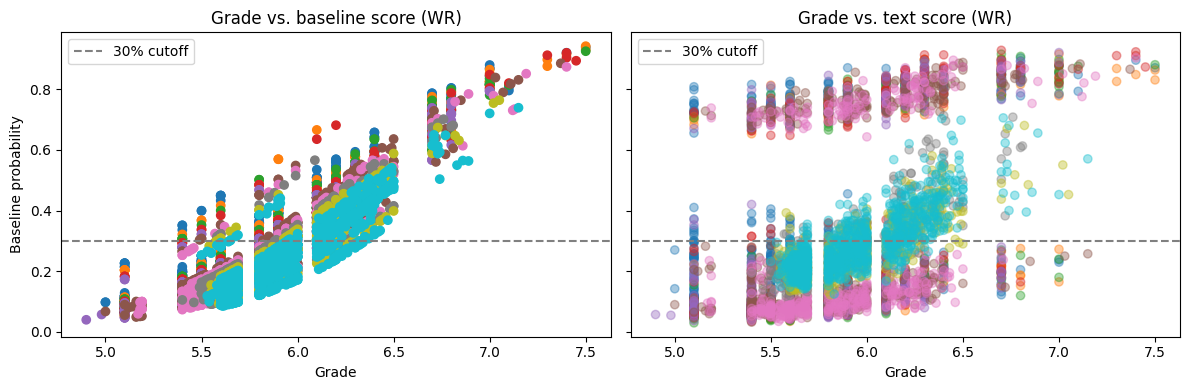

In [115]:
import matplotlib.pyplot as plt
tee_df = df[df['player_name'].str.contains('Tee Higgins', case=False)].head(1)
if tee_df.empty:
    raise ValueError('Could not find Tee Higgins in the dataset')
tee = tee_df
text_pipe = pipe.named_steps['features'].transformer_list[0][1]
year_norm = text_pipe.named_steps['year_norm']
text_terms = year_norm.vectorizer.get_feature_names_out()
tee_text = year_norm.transform(tee[['scouting_text_tagged', 'year']])
text_series = pd.Series(tee_text.ravel(), index=text_terms)
print('Tee Higgins baseline cohort info:', tee[['year', 'Pos_Group', 'grade']].to_dict(orient='records')[0])
print('Top text deviations for Tee Higgins:')
print(text_series.nlargest(8))

baseline_preproc = baseline_pipe.named_steps['preproc']
baseline_input = tee[['grade', 'Pos_Group', 'year']]
baseline_values = baseline_preproc.transform(baseline_input).toarray().ravel()
feature_names = baseline_preproc.get_feature_names_out()
coef = baseline_pipe.named_steps['lr'].coef_.ravel()
contrib = pd.Series(coef * baseline_values, index=feature_names)
print('Baseline probability contributions (intercept %.3f):' % baseline_pipe.named_steps['lr'].intercept_[0])
print(contrib.sort_values(ascending=False))

wr = df.copy()
wr = wr[wr['grade'] > 0]
wr['text_score'] = pipe.predict_proba(wr)[:, 1]
wr['baseline_score'] = baseline_pipe.predict_proba(wr)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(wr['grade'], wr['baseline_score'], c=wr['year'], cmap='tab10', alpha=1)
axes[0].set_title('Grade vs. baseline score (WR)')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Baseline probability')
axes[0].axhline(0.3, color='gray', ls='--', label='30% cutoff')
axes[0].legend()
axes[1].scatter(wr['grade'], wr['text_score'],c=wr['year'], cmap='tab10', alpha=0.4, )
axes[1].set_title('Grade vs. text score (WR)')
axes[1].set_xlabel('Grade')
axes[1].axhline(0.3, color='gray', ls='--', label='30% cutoff')
axes[1].legend()
# Create a mappable that knows the range of your data
#sm = plt.cm.ScalarMappable(cmap='tab10', norm=plt.Normalize(vmin=wr['year'].min(), vmax=wr['year'].max()))
#fig.colorbar(sm, ax=axes, label='Year')
plt.tight_layout()

In [116]:
from matplotlib import lines

norm = plt.Normalize(wr['year'].min(), wr['year'].max())
cmap = plt.colormaps['tab10']
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

for ax, score, title in zip(
    axes,
    ['baseline_score', 'text_score'],
    ['Grade vs. baseline score (WR)', 'Grade vs. text score (WR)']
):
    ax.scatter(
        wr['grade'],
        wr[score],
        c=wr['year'],
        cmap=cmap,
        norm=norm,
        alpha=0.6
    )
    ax.set_title(title)
    ax.set_xlabel('Grade')
    if score == 'baseline_score':
        ax.set_ylabel('Baseline probability')
    ax.axhline(0.3, color='gray', ls='--')

year_handles = [
    lines.Line2D([0], [0], marker='o', linestyle='', color=cmap(norm(year)), label=str(year))
    for year in sorted(wr['year'].unique())
]
cutoff_handle = lines.Line2D([0], [0], color='gray', ls='--', label='30% cutoff')
axes[0].legend(handles=year_handles + [cutoff_handle], title='Year')
axes[1].legend(handles=[cutoff_handle])

fig.colorbar(sm, ax=axes.ravel().tolist(), label='Year')
plt.tight_layout()


<Figure size 640x480 with 0 Axes>

### Top residuals vs. baseline

Highlight the players where the text model (and the ensemble) deviates most from the grade+Pos_Group baseline so you can inspect what language it likes or dislikes.

In [117]:
residuals = train_preds.assign(
    residual=train_preds['text_score'] - train_preds['baseline_score'],
    ensemble_residual=train_preds['ensemble_pred'] - train_preds['baseline_score'],
)
top_positive = residuals.nlargest(8, 'residual')[['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'residual', 'ensemble_residual', 'made_it_contract']]
top_negative = residuals.nsmallest(8, 'residual')[['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'residual', 'ensemble_residual', 'made_it_contract']]
print('Top text > baseline residuals:')
print(top_positive.to_string(index=False))
print('Top text << baseline (neg residuals):')
print(top_negative.to_string(index=False))

Top text > baseline residuals:
 year        player_name Pos_Group  grade  text_score  baseline_score  residual  ensemble_residual  made_it_contract
 2014      Roosevelt Nix        RB    5.1      0.8075        0.081109  0.726391           0.420141                 1
 2014 Kevin Pierre-Louis      EDGE    5.1      0.7975        0.098470  0.699030           0.464030                 1
 2014      Quincy Enunwa        WR    5.1      0.7625        0.064281  0.698219           0.466969                 1
 2014     Chandler Jones        WR    5.1      0.7475        0.064281  0.683219           0.419469                 1
 2019       Ashton Dulin        WR    5.4      0.7550        0.083287  0.671713           0.661713                 1
 2017        Zach Pascal        WR    5.4      0.7600        0.094125  0.665875           0.382125                 1
 2014         John Brown        WR    5.4      0.7775        0.112752  0.664748           0.394748                 1
 2018         Mike Boone        R

## Held-out residual & SHAP exploration

Use the fitted pipelines to inspect the 2022-2025 cohort, surface the players whose text+meta model scores bump them the most above the grade+Pos_Group baseline, and then explain which features (including year-normalized TF-IDF tokens) carry that lift.

In [121]:
pos_filter = None
mask = df.year.between(2022, 2025)
future_df = df.loc[mask].copy()
future_df['text_score'] = pipe.predict_proba(future_df)[:, 1]
future_df['baseline_score'] = baseline_pipe.predict_proba(future_df)[:, 1]
future_df['residual'] = future_df['text_score'] - future_df['baseline_score']
if pos_filter is None:
    subset = future_df
else:
    groups = pos_filter if isinstance(pos_filter, (list, tuple, set)) else [pos_filter]
    subset = future_df[future_df['Pos_Group'].isin(groups)]
print(f"Analyzing {len(subset)} rows ({'all positions' if pos_filter is None else ','.join(sorted(subset['Pos_Group'].unique()))})")
subset = subset.sort_values('residual', ascending=False)
display_cols = ['year', 'player_name', 'Pos_Group', 'grade', 'baseline_score', 'text_score', 'residual']
print('Top 10 positive residuals (text score - baseline score)')
print(subset[display_cols].head(50).to_string(index=False))

Analyzing 1853 rows (all positions)
Top 10 positive residuals (text score - baseline score)
 year       player_name Pos_Group  grade  baseline_score  text_score  residual
 2025          Cam Ward        QB   6.39        0.398382      0.7025  0.304118
 2025      Jalen Milroe        QB   6.14        0.283978      0.5675  0.283522
 2022     Kenny Pickett        QB   6.40        0.452552      0.7125  0.259948
 2022      Malik Willis        QB   6.41        0.457637      0.6950  0.237363
 2022        Sam Howell        QB   6.22        0.363677      0.6000  0.236323
 2025       Will Howard        QB   5.90        0.195145      0.4200  0.224855
 2025   Shedeur Sanders        QB   6.30        0.355088      0.5725  0.217412
 2024      Patrick Paul        OL   6.22        0.403635      0.6200  0.216365
 2025       Isas Waxter        DB   5.69        0.149090      0.3550  0.205910
 2025    Dillon Gabriel        QB   6.10        0.267600      0.4700  0.202400
 2022     Pierre Strong        RB   6.1

 98%|===================| 394/400 [00:40<00:00]        

Top SHAP-contributing features for this slice (bigger values push text_score up)
               feature  mean_abs_shap
      num__total_score       0.031241
            num__grade       0.015798
 num__production_score       0.015600
num__athleticism_score       0.010444
             text::str       0.008459
             text::wkn       0.007684
             text::ovr       0.007340
           text::catch       0.003499
           text::route       0.003305
            text::lack       0.002769
          text::enough       0.002627
          text::unable       0.001966
          text::handle       0.001861
   text::below average       0.001815
         text::however       0.001678


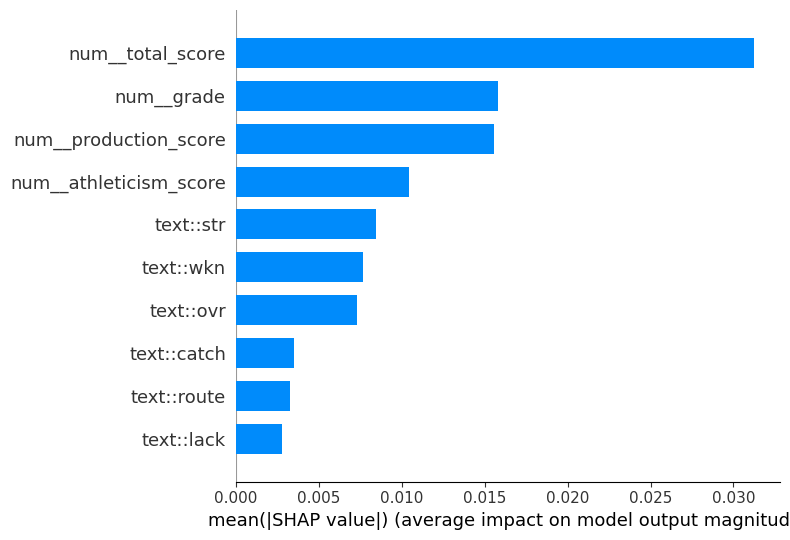

In [119]:
import shap
if subset.empty:
    print('No rows match the filter; skipping SHAP computation')
else:
    focus = subset.head(200)
    preprocessor = pipe.named_steps['features']
    rf = pipe.named_steps['rf']
    background = preprocessor.transform(train_df.sample(min(300, len(train_df)), random_state=0))
    explainer = shap.TreeExplainer(rf, data=background, model_output='probability')
    X_focus = preprocessor.transform(focus)
    shap_values = explainer.shap_values(X_focus)
    if isinstance(shap_values, list):
        shap_positive = shap_values[1]
    elif shap_values.ndim == 3:
        shap_positive = shap_values[..., 1]
    else:
        shap_positive = shap_values
    text_pipe = preprocessor.transformer_list[0][1]
    vectorizer = text_pipe.named_steps['year_norm'].vectorizer
    text_features = [f"text::{term}" for term in vectorizer.get_feature_names_out()]
    meta_transformer = preprocessor.transformer_list[1][1]
    try:
        meta_features = list(meta_transformer.get_feature_names_out())
    except AttributeError:
        meta_features = numeric_features + cat_features
    feature_names = text_features + list(meta_features)
    X_df = pd.DataFrame(X_focus, columns=feature_names)
    mean_abs = np.abs(shap_positive).mean(axis=0)
    feature_importance = (
        pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs})
        .sort_values('mean_abs_shap', ascending=False)
    )
    print('Top SHAP-contributing features for this slice (bigger values push text_score up)')
    print(feature_importance.head(15).to_string(index=False))
    shap.summary_plot(shap_positive, X_df, feature_names=feature_names, max_display=10, plot_type='bar')


## Contrast: Chandler Jones (boom) vs. Reggie Ragland (bust)

List the text/baseline signals the models relied on for these two edge prospects so you can see why one was right and one was wrong.

In [120]:
players = ['Mike Boone', 'Reggie Ragland']
insights = []
text_pipe = pipe.named_steps['features'].transformer_list[0][1]
year_norm = text_pipe.named_steps['year_norm']
for name in players:
    candidate = df[df['player_name'].str.contains(name, case=False, regex=False)]
    if candidate.empty:
        print(f'No record for {name} (string match failed)')
        continue
    candidate_row = candidate.iloc[0]
    row_df = candidate_row.to_frame().T
    text_vec = year_norm.transform(row_df[['scouting_text_tagged', 'year']])
    text_terms = year_norm.vectorizer.get_feature_names_out()
    term_scores = pd.Series(text_vec.ravel(), index=text_terms).nlargest(8)
    print(f'{name} top text deviations:')
    print(term_scores)
    baseline_input = pd.DataFrame([{ 'grade': candidate_row['grade'], 'Pos_Group': candidate_row['Pos_Group'], 'year': candidate_row['year'] }])
    baseline_preproc = baseline_pipe.named_steps['preproc']
    baseline_values = baseline_preproc.transform(baseline_input).toarray().ravel()
    feature_names = baseline_preproc.get_feature_names_out()
    coef = baseline_pipe.named_steps['lr'].coef_.ravel()
    contrib = pd.Series(coef * baseline_values, index=feature_names).sort_values(ascending=False)
    print(f"{name} baseline contributions (intercept {baseline_pipe.named_steps['lr'].intercept_[0]:.3f}):", contrib.head(6))
    preds = {
        'text_score': pipe.predict_proba(row_df)[:, 1][0],
        'baseline_score': baseline_pipe.predict_proba(baseline_input)[:, 1][0],
    }
    print(f"{name} text/baseline scores:", preds)

Mike Boone top text deviations:
failed           0.222799
testing          0.219854
explosive        0.141307
running style    0.135713
tight quarter    0.127284
tremendous       0.127232
run lane         0.126912
finesse          0.126147
dtype: float64
Mike Boone baseline contributions (intercept -0.790): pos__Pos_Group_DB     -0.0
pos__Pos_Group_DT     -0.0
pos__Pos_Group_EDGE   -0.0
pos__Pos_Group_LB      0.0
pos__Pos_Group_WR     -0.0
pos__Pos_Group_OL      0.0
dtype: float64
Mike Boone text/baseline scores: {'text_score': np.float64(0.725), 'baseline_score': np.float64(0.06321979023915286)}
Reggie Ragland top text deviations:
inside linebacker    0.216388
showed               0.154898
linebacker           0.145674
three season         0.126406
sub                  0.125579
hitter               0.124478
run fit              0.123766
man cover            0.123241
dtype: float64
Reggie Ragland baseline contributions (intercept -0.790): grade__grade           2.383937
pos__Pos_Group_